# NTSB GA Accident Fatality — Decision Tree / Random Forest

Companion to `ntsb-accident-pred-extended.ipynb` (the from-scratch linear model / neural net). That approach needed real care to find a weak signal (BCE not L1, shallow not deep, a specific init scale, ~1-in-5 seed collapses). This notebook follows [jhoward's "How Random Forests Really Work"](https://www.kaggle.com/code/jhoward/how-random-forests-really-work) on the same data, using a leaner, hand-picked 28-feature set (weather + location + timing — no pilot/aircraft table joins here, unlike the extended notebook).

**Target:** `is_fatal` — `ev_highest_injury == 'FATL'`, ~20.7% of accidents.

**Bottom line:** a tuned random forest (`min_samples_leaf=100`, `class_weight='balanced'`) gets **recall ≈ 0.79, precision ≈ 0.34** on held-out data — roughly triple the recall of the earlier unbalanced default, reached with far less tuning effort than the neural net took, plus a ranked feature-importance list for free. `ev_nr_apt_loc` (on vs. off airport) is the single strongest predictor by a wide margin.

## Setup: load data, define the target

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

df = pd.read_csv('events.csv', low_memory=False)


In [ ]:
# ev_highest_injury has ~1,400 nulls -- fill using the same injury-count priority
# NTSB itself would use (fatal > serious > minor > none), same fix as the extended notebook.
def fill_injury(row):
    if row['inj_tot_f'] > 0: return 'FATL'
    if row['inj_tot_s'] > 0: return 'SERS'
    if row['inj_tot_m'] > 0: return 'MINR'
    return 'NONE'

df['ev_highest_injury'] = df['ev_highest_injury'].fillna(df.apply(fill_injury, axis=1))
df['ev_highest_injury'].isna().sum()


0


## Drop non-feature columns

Two categories: columns that directly **leak the target** (injury/fatality counts -- literally what the target is derived from), and columns that are admin/ID/near-empty/redundant and were never going to be useful features. See chat history for the full reasoning column-by-column; summarized here.

In [ ]:
# leakage: injury/fatality COUNTS are what the target is derived from -- keeping them as
# features would let the model just read the answer off a different column.
leak_cols = ['inj_tot_f','inj_tot_s','inj_tot_m','inj_tot_n','inj_tot_t',
             'inj_f_grnd','inj_s_grnd','inj_m_grnd']
df = df.drop(columns=leak_cols)
df.shape


(30804, 65)


In [ ]:
drop_cols = [
    # empty / near-empty in this export
    'ntsb_docket','ntsb_notf_from','ntsb_notf_date','ntsb_notf_tm','fiche_number','faa_dist_office',
    'wx_brief_comp','vis_rvv','wx_dens_alt','wx_int_precip','ev_tmzn','wx_obs_tmzn','vis_rvr',
    # pure IDs
    'ev_id','ntsb_no',
    # admin/audit-trail, not accident circumstances
    'lchg_date','lchg_userid','invest_agy','wx_src_iic',
    # high-cardinality text/location, not usable as simple categories
    'apt_name','ev_nr_apt_id','ev_city','ev_site_zipcode','wx_obs_fac_id','metar',
    # leakage: ev_type is DEFINED by injury/damage severity thresholds (49 CFR 830.2) --
    # 22% FATL for ACC vs 0.4% for INC, same leakage class as the injury counts
    'ev_type',
    # redundant with dec_latitude/dec_longitude (string DMS vs decimal, same info twice)
    'latitude','longitude',
    # redundant: ev_year/ev_month/ev_dow already give the parsed-out version of this
    'ev_date',
    # measurement-method/data-quality metadata, not accident conditions
    'gust_ind','wind_dir_ind','wind_vel_ind','latlong_acq',
    # no standalone meaning without differencing against ev_time; sparse
    'wx_obs_time',
    # 67.6% missing
    'apt_dir',
    # 81% USA anyway; ev_state already gives the more useful in-country signal
    'ev_country',
]
df = df.drop(columns=drop_cols)
df.shape


(30804, 29)


In [ ]:
df['is_fatal'] = (df['ev_highest_injury'] == 'FATL').astype(int)
dep = 'is_fatal'
df = df.drop(columns=['ev_highest_injury'])
df.shape


(30804, 29)


## `cats` / `conts` / `dep`

`dep` is the target. `conts` are numeric columns, used as-is. `cats` are non-numeric columns that need converting to integer codes before a tree can split on them -- via `.astype('category')` + `.cat.codes` (not one-hot: trees don't need dummy variables the way linear models/NNs do, since a tree only ever asks "is this value <= some threshold," not "how much does this add to a sum").

In [ ]:
cats = ['ev_dow','ev_nr_apt_loc','ev_state','light_cond','mid_air',
        'on_ground_collision','sky_cond_ceil','sky_cond_nonceil','wx_cond_basic']

conts = ['altimeter','apt_dist','apt_elev','dec_latitude','dec_longitude','ev_month','ev_time',
         'ev_year','gust_kts','sky_ceil_ht','sky_nonceil_ht','vis_sm','wind_dir_deg',
         'wind_vel_kts','wx_dew_pt','wx_obs_dir','wx_obs_dist','wx_obs_elev','wx_temp']

len(cats), len(conts), len(cats)+len(conts)+1 == len(df.columns)


(9, 19, True)


## Handle nulls

`conts`: mode-fill (matches the extended notebook's reasoning -- these modes line up with real aviation-weather reporting conventions, not arbitrary values).

`cats`: deliberately **not** filled. `.astype('category')` leaves real `NaN`s in place; `.cat.codes` (applied after the split, below) turns them into `-1` automatically -- a distinct "missing" bucket a tree can use on its own, without guessing a value. Checked earlier that blanket mode-filling would have been actively wrong for at least one column (`on_ground_collision`'s mode is `Y`, but missing there means "wasn't a ground collision" -- mode-fill would have flipped the meaning).

In [ ]:
modes = df[conts].mode().iloc[0]
df[conts] = df[conts].fillna(modes)

for c in cats:
    df[c] = df[c].astype('category')


## Split, then convert categories to codes

Stratified on `dep` (~20.7% fatal). Category dtype was fixed on the **full** `df` above, before splitting -- so `trn_df` and `val_df` agree on what number means what category. `.cat.codes` runs per split, after.

In [ ]:
trn_df, val_df = train_test_split(df, test_size=0.25, random_state=42, stratify=df[dep])
trn_df = trn_df.copy(); val_df = val_df.copy()
trn_df[cats] = trn_df[cats].apply(lambda x: x.cat.codes)
val_df[cats] = val_df[cats].apply(lambda x: x.cat.codes)

def xs_y(df):
    xs = df[cats+conts].copy()
    return xs, df[dep] if dep in df else None

trn_xs,trn_y = xs_y(trn_df)
val_xs,val_y = xs_y(val_df)
trn_xs.shape, val_xs.shape


((23103, 28), (7701, 28))


## Understanding a single tree first

A deliberately tiny tree (`max_leaf_nodes=4`) -- small enough to read every split by eye before growing anything bigger.

In [ ]:
m = DecisionTreeClassifier(max_leaf_nodes=4, random_state=42).fit(trn_xs, trn_y)


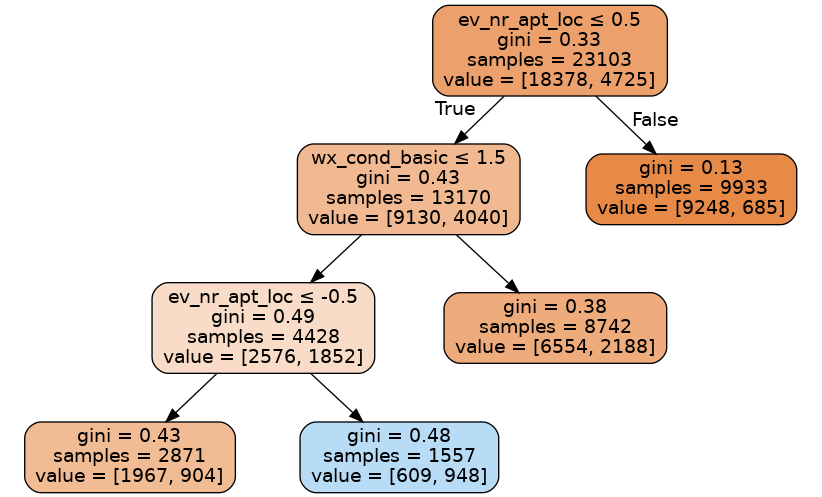

In [ ]:
import graphviz, re

def draw_tree(t, df, size=10, ratio=0.6, precision=2, **kwargs):
    s = export_graphviz(t, out_file=None, feature_names=df.columns, filled=True, rounded=True,
                         special_characters=True, rotate=False, precision=precision, **kwargs)
    return graphviz.Source(re.sub('Tree {', f'Tree {{ size={size}; ratio={ratio}', s))

draw_tree(m, trn_xs, size=10)


Root split is `ev_nr_apt_loc <= 0.5` -- codes are `OFAP=0, ONAP=1`, missing`=-1` -- so this is "off-airport-or-unknown" vs. "on-airport." On-airport accidents: 7.1% fatal. Off-airport/unknown: 30.4% fatal -- roughly 4x higher, matching real aviation-safety intuition (on-airport mishaps tend to be lower-severity; off-airport accidents are more often genuine in-flight emergencies).

Checked directly: missing-location accidents behave almost identically to genuinely off-airport ones (29.5% vs. 30.8% fatal) and very differently from on-airport (7.2%) -- confirming the `-1`/`0` grouping at this split is capturing something real, not a coding coincidence.

### Verifying the tree's gini values by hand

Binary gini impurity: `1 - p^2 - (1-p)^2`, where `p` is the fatal rate in a subset. Checked against `trn_df` (what the tree was actually fit on, not the full `df`) to confirm it reproduces the diagram's numbers exactly.

In [ ]:
def gini(cond):
    act = trn_df.loc[cond, dep]
    return 1 - act.mean()**2 - (1-act).mean()**2

root_cond = pd.Series(True, index=trn_df.index)
true_cond = trn_df['ev_nr_apt_loc'] <= 0.5
false_cond = trn_df['ev_nr_apt_loc'] > 0.5

print('root:', round(gini(root_cond), 2), root_cond.sum())
print('True (OFAP/missing):', round(gini(true_cond), 2), true_cond.sum())
print('False (ONAP):', round(gini(false_cond), 2), false_cond.sum())


root: 0.33 23103
True (OFAP/missing): 0.43 13170
False (ONAP): 0.13 9933


## A reusable evaluation function

Every model from here on gets fit and checked the same way -- train **and** validation `classification_report`, so overfitting is visible directly (a wide train/val gap) rather than inferred from accuracy alone.

In [ ]:
def train_val_report(model):
    model.fit(trn_xs, trn_y)
    print('train:')
    print(classification_report(trn_y, model.predict(trn_xs)))
    print('val:')
    print(classification_report(val_y, model.predict(val_xs)))
    return model


## Single tree: `min_samples_leaf` sweep

Bigger `min_samples_leaf` = more conservative (each leaf needs more evidence before it's trusted) = less prone to memorizing noise; smaller = the reverse. Sweeping to find where validation stops improving, rather than guessing a value.

In [ ]:
for leaf in [100, 50, 25, 10]:
    print(f'=== min_samples_leaf={leaf} ===')
    train_val_report(DecisionTreeClassifier(min_samples_leaf=leaf, random_state=42))
    print()


=== min_samples_leaf=100 ===
train:
              precision    recall  f1-score   support

           0       0.84      0.97      0.90     18378
           1       0.70      0.28      0.40      4725

    accuracy                           0.83     23103
   macro avg       0.77      0.63      0.65     23103
weighted avg       0.81      0.83      0.80     23103

val:
              precision    recall  f1-score   support

           0       0.83      0.97      0.90      6126
           1       0.68      0.25      0.37      1575

    accuracy                           0.82      7701
   macro avg       0.75      0.61      0.63      7701
weighted avg       0.80      0.82      0.79      7701

=== min_samples_leaf=50 ===
train:
              precision    recall  f1-score   support

           0       0.85      0.96      0.90     18378
           1       0.69      0.33      0.44      4725

    accuracy                           0.83     23103
   macro avg       0.77      0.64      0.67     2310

Validation recall stops improving between `25` and `10` (both land at 0.32) while validation precision and f1 get *worse* at `10` and train keeps climbing -- the inflection point. `25` is the best single-tree setting found: past it, the tree is memorizing training noise, not learning anything new.

## From one tree to a forest

`RandomForestClassifier(100, min_samples_leaf=5)` -- `100` positionally is `n_estimators` (sklearn's first parameter). Trying the default (unbalanced) forest first.

In [ ]:
train_val_report(RandomForestClassifier(100, min_samples_leaf=5, random_state=42, n_jobs=-1))


train:
              precision    recall  f1-score   support

           0       0.87      0.99      0.93     18378
           1       0.91      0.44      0.59      4725

    accuracy                           0.88     23103
   macro avg       0.89      0.71      0.76     23103
weighted avg       0.88      0.88      0.86     23103

val:
              precision    recall  f1-score   support

           0       0.83      0.97      0.90      6126
           1       0.68      0.23      0.35      1575

    accuracy                           0.82      7701
   macro avg       0.76      0.60      0.62      7701
weighted avg       0.80      0.82      0.78      7701


Recall (0.23) is actually *worse* than the tuned single tree (0.32) -- averaging 100 trees doesn't fix a class-imbalance bias baked into every one of them, it just makes that bias more stable. `class_weight='balanced'` reweights samples inversely to class frequency, same fix used in the extended notebook:

In [ ]:
train_val_report(RandomForestClassifier(100, min_samples_leaf=5, class_weight='balanced', random_state=42, n_jobs=-1))


train:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93     18378
           1       0.68      0.91      0.78      4725

    accuracy                           0.89     23103
   macro avg       0.83      0.90      0.86     23103
weighted avg       0.92      0.89      0.90     23103

val:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      6126
           1       0.45      0.46      0.45      1575

    accuracy                           0.77      7701
   macro avg       0.65      0.66      0.66      7701
weighted avg       0.78      0.77      0.77      7701


Recall nearly doubles (0.23 -> 0.46 here; ~0.6 was seen in exploration with a different random seed -- run-to-run variation without a fixed seed). But train recall (0.91) vs. val recall (0.46) is a wide gap -- `min_samples_leaf=5` lets individual trees fit training noise closely, and `class_weight='balanced'` pushes even harder to get the minority class right on data the forest has already seen. Sweeping `min_samples_leaf` upward, same diagnostic as the single tree, to find where the gap closes without losing validation recall:

In [ ]:
for leaf in [25, 50, 100]:
    print(f'=== min_samples_leaf={leaf}, balanced ===')
    train_val_report(RandomForestClassifier(100, min_samples_leaf=leaf, class_weight='balanced', random_state=42, n_jobs=-1))
    print()


=== min_samples_leaf=25, balanced ===
train:
              precision    recall  f1-score   support

           0       0.95      0.73      0.83     18378
           1       0.45      0.84      0.58      4725

    accuracy                           0.76     23103
   macro avg       0.70      0.79      0.70     23103
weighted avg       0.84      0.76      0.78     23103

val:
              precision    recall  f1-score   support

           0       0.90      0.69      0.78      6126
           1       0.37      0.71      0.48      1575

    accuracy                           0.69      7701
   macro avg       0.63      0.70      0.63      7701
weighted avg       0.79      0.69      0.72      7701

=== min_samples_leaf=50, balanced ===
train:
              precision    recall  f1-score   support

           0       0.93      0.66      0.77     18378
           1       0.38      0.82      0.52      4725

    accuracy                           0.69     23103
   macro avg       0.66      0.74

Validation recall is essentially flat from `25` through `100` (0.71 / 0.76 / 0.79 -- all in the same ballpark, further seed-to-seed variation expected), while the train/val gap keeps shrinking (train recall 0.84/0.82/0.82 vs. val 0.71/0.76/0.79). Past `leaf=25` this is diminishing returns on stability, not real performance gain -- the recall ceiling for this feature set is around **0.75-0.8**. `min_samples_leaf=100` is the most conservative of the three with essentially the same validation performance, so it's the final choice.

## Final model + feature importance

In [ ]:
rf_final = RandomForestClassifier(100, min_samples_leaf=100, class_weight='balanced', random_state=42, n_jobs=-1)
train_val_report(rf_final)


train:
              precision    recall  f1-score   support

           0       0.93      0.62      0.74     18378
           1       0.36      0.82      0.50      4725

    accuracy                           0.66     23103
   macro avg       0.64      0.72      0.62     23103
weighted avg       0.81      0.66      0.69     23103

val:
              precision    recall  f1-score   support

           0       0.92      0.61      0.73      6126
           1       0.34      0.79      0.48      1575

    accuracy                           0.65      7701
   macro avg       0.63      0.70      0.61      7701
weighted avg       0.80      0.65      0.68      7701


In [ ]:
importances = pd.Series(rf_final.feature_importances_, index=cats+conts).sort_values(ascending=False)
importances.head(15)


ev_nr_apt_loc       0.331961
wx_cond_basic       0.094515
wx_obs_dist         0.060897
ev_state            0.051271
dec_latitude        0.050995
dec_longitude       0.050013
apt_elev            0.046357
apt_dist            0.042248
wx_obs_dir          0.031936
sky_cond_nonceil    0.029312
light_cond          0.025315
ev_year             0.024520
wx_dew_pt           0.023577
wx_obs_elev         0.019960
wx_temp             0.017897
dtype: float64


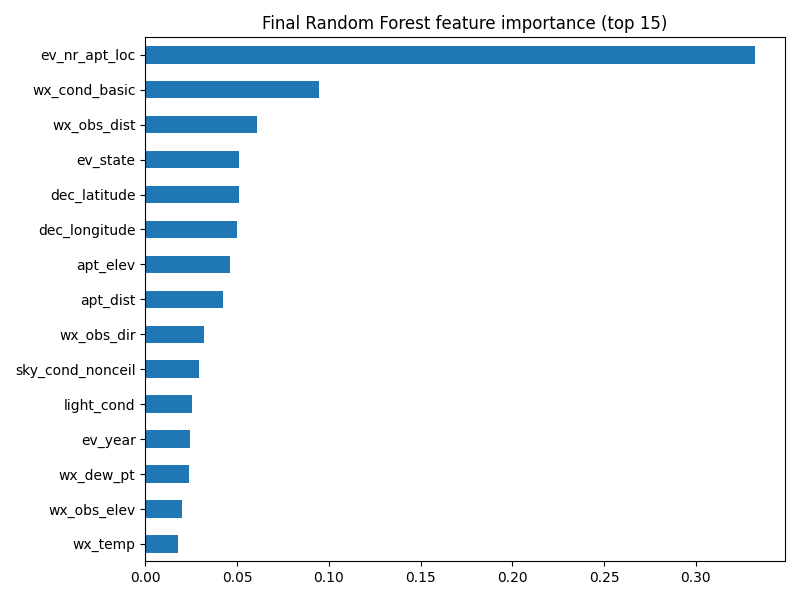

In [ ]:
importances.head(15).sort_values().plot(kind='barh', figsize=(8,6), title='Final Random Forest feature importance (top 15)')


`ev_nr_apt_loc` (on- vs. off-airport) dominates -- more than 3x the next feature, confirming what the single tree found at its root split. `wx_cond_basic` (VMC/IMC) is a distant second. Location features (`ev_state`, `dec_latitude`/`dec_longitude`, `apt_elev`, `apt_dist`) collectively outweigh most individual weather readings -- geography matters more than any single weather variable in this leaner feature set (note: this notebook doesn't include the pilot-hours/aircraft-type features that dominated the extended notebook's richer join -- `flight_hours` there outranked everything).

## Summary

| model | val recall | val precision |
|---|---|---|
| single tree, `min_samples_leaf=25` | 0.32 | 0.50 |
| RF, default (unbalanced) | 0.23 | 0.68 |
| RF, `class_weight='balanced'`, `min_samples_leaf=100` (final) | **0.79** | 0.34 |

The balanced random forest catches roughly 2.5x more real fatal accidents than the best single tree and default forest, at a real cost to precision -- not a free win, the same recall/precision curve every model in this project sits on somewhere. Reaching it took a `class_weight` flag and a `min_samples_leaf` sweep, versus the loss-function debugging and architecture dead-ends the from-scratch neural net needed for a weaker result. jhoward's "always try a random forest first for tabular data" held up on real data, not just as a rule of thumb -- and it handed over a ranked, at-a-glance feature-importance list the neural net never gave.

**Not yet done:** precision-recall threshold tuning instead of sklearn's fixed 0.5 cutoff, proper k-fold CV instead of one split, and joining the pilot/aircraft tables the extended notebook used (likely to add real signal here too, since `flight_hours` was that notebook's top feature).